# Notebook 04 — Activation Cache Inspection

Validates the Phase 4 activation caches and runs PCA/UMAP sanity checks to confirm the hidden states encode meaningful structure across layers.

In [1]:
import os, sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
sys.path.insert(0, str(project_root))

from src.utils.reproducibility import set_all_seeds
set_all_seeds(42)
print("Working directory:", os.getcwd())

Working directory: /Users/vraj21/Desktop/Projects/LLM Reranker


## 1  Validate caches (shape, NaN/Inf check)

In [2]:
from src.activations.cache_manager import load_activation_cache, validate_cache, assert_pairs_aligned
from src.utils.io import load_parquet

for name in ["scifact", "nfcorpus"]:
    acts, manifest = load_activation_cache(name)
    validate_cache(acts, manifest)
    pairs_df = load_parquet(f"data/interim/{name}/query_doc_pairs.parquet")
    assert_pairs_aligned(manifest, pairs_df)
    print(f"\n{name}: {manifest['n_pairs']} pairs x {manifest['n_layers']} layers x {manifest['hidden_dim']} dims — OK")

2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Loaded 28 layers from data/caches/activations/scifact (6000 pairs × 1536 dims)
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Validating cache: 28 layers, 6000 pairs, hidden_dim=1536
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Cache validation passed.
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Pair alignment check passed.

scifact: 6000 pairs x 28 layers x 1536 dims — OK
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Loaded 28 layers from data/caches/activations/nfcorpus (6460 pairs × 1536 dims)
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Validating cache: 28 layers, 6460 pairs, hidden_dim=1536
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Cache validation passed.
2026-03-29 07:21:29 | INFO     | src.activations.cache_manager | Pair alignment check passed.

nfcorpus: 6460 pairs x 28 layers x 1536 dims — O

## 2  Activation norms across layers

2026-03-29 07:21:36 | INFO     | src.activations.cache_manager | Loaded 28 layers from data/caches/activations/scifact (6000 pairs × 1536 dims)


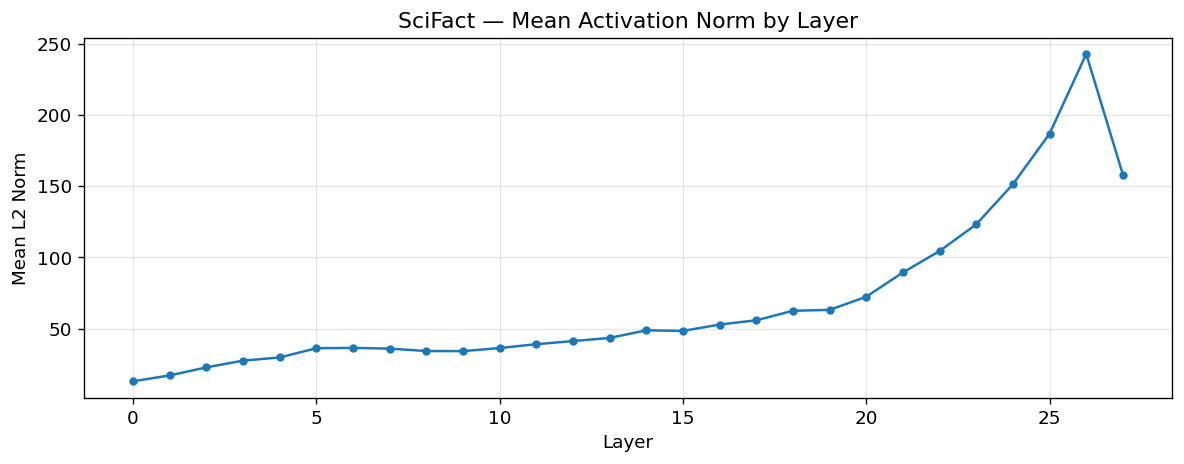

Saved.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

acts, manifest = load_activation_cache("scifact")
n_layers = manifest["n_layers"]

mean_norms = []
for i in range(n_layers):
    norms = np.linalg.norm(acts[i].astype(np.float32), axis=1)
    mean_norms.append(norms.mean())

plt.figure(figsize=(10, 4))
plt.plot(range(n_layers), mean_norms, marker="o", markersize=4)
plt.xlabel("Layer")
plt.ylabel("Mean L2 Norm")
plt.title("SciFact — Mean Activation Norm by Layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
Path("outputs/midproject/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/midproject/figures/activation_norms.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 3  PCA: early vs late layer (layer 0 vs layer 27)

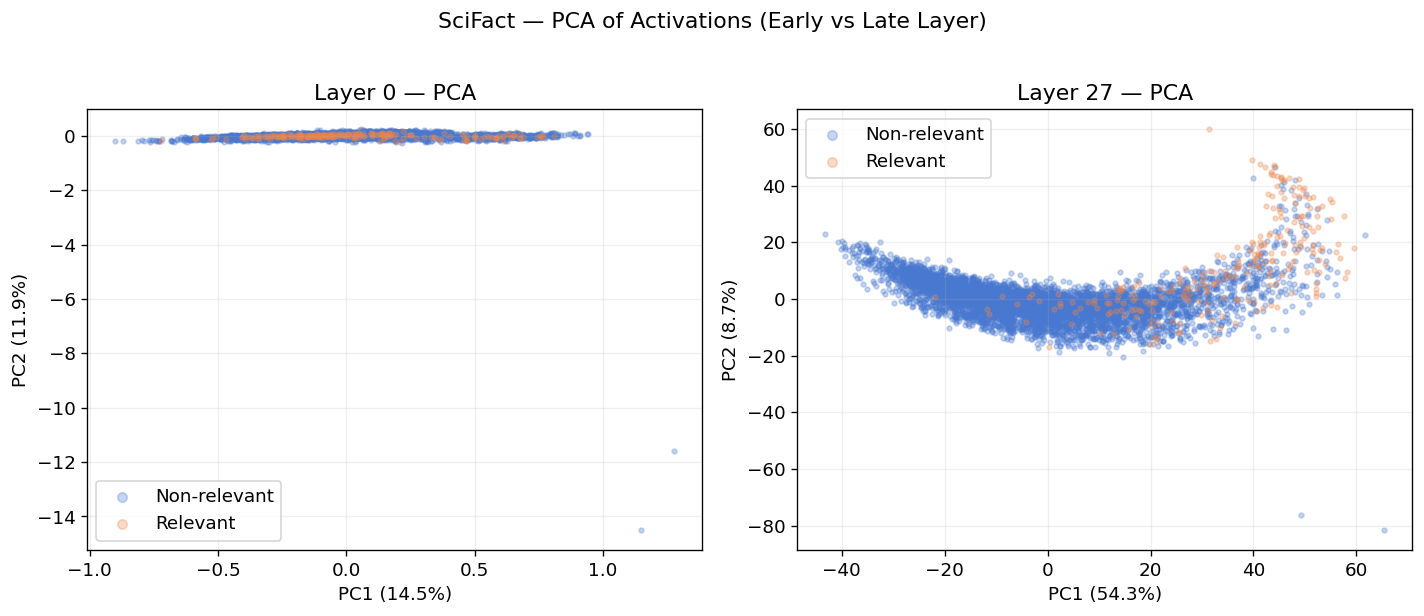

Saved.


In [4]:
from sklearn.decomposition import PCA
import pandas as pd

pairs_df = load_parquet("data/interim/scifact/query_doc_pairs.parquet")
labels = pairs_df["is_relevant"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, layer_idx in zip(axes, [0, 27]):
    X = acts[layer_idx].astype(np.float32)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    
    for label, color, name in [(False, "#4878d0", "Non-relevant"), (True, "#ee854a", "Relevant")]:
        mask = labels == label
        ax.scatter(coords[mask, 0], coords[mask, 1], c=color, alpha=0.3,
                   s=8, label=name, rasterized=True)
    
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
    ax.set_title(f"Layer {layer_idx} — PCA")
    ax.legend(markerscale=2)
    ax.grid(True, alpha=0.2)

plt.suptitle("SciFact — PCA of Activations (Early vs Late Layer)", y=1.02)
plt.tight_layout()
plt.savefig("outputs/midproject/figures/activation_pca.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 4  PCA across all layers: relevance separability

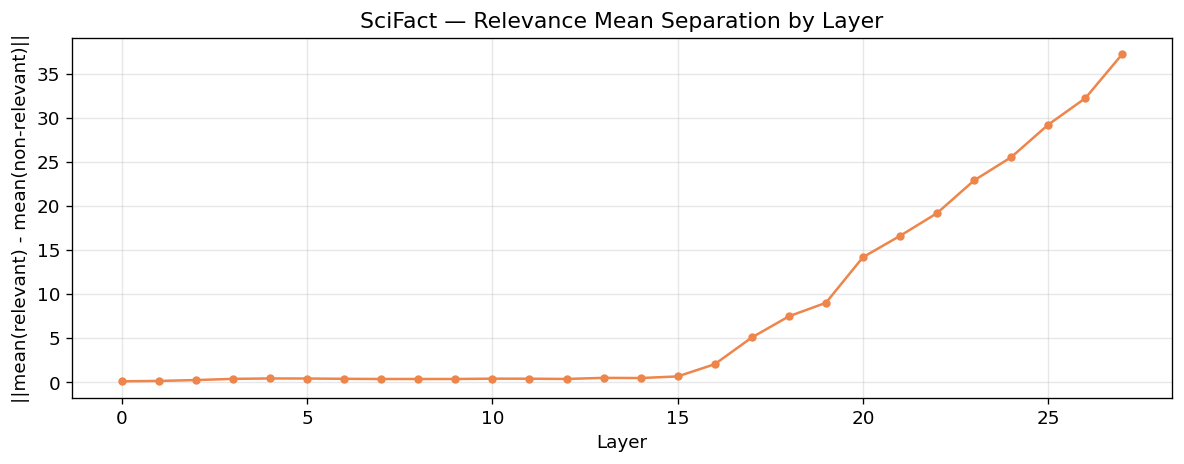

Saved.


In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# For each layer compute LDA score (proxy for linear separability by relevance)
lda_scores = []
for i in range(n_layers):
    X = acts[i].astype(np.float32)
    # Use variance of projected means as proxy (fast, no CV needed)
    X_rel = X[labels == True].mean(axis=0)
    X_nrel = X[labels == False].mean(axis=0)
    sep = np.linalg.norm(X_rel - X_nrel)
    lda_scores.append(sep)

plt.figure(figsize=(10, 4))
plt.plot(range(n_layers), lda_scores, marker="o", markersize=4, color="#ee854a")
plt.xlabel("Layer")
plt.ylabel("||mean(relevant) - mean(non-relevant)||")
plt.title("SciFact — Relevance Mean Separation by Layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/midproject/figures/activation_relevance_separation.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 5  Cache summary

In [6]:
import json

for name in ["scifact", "nfcorpus"]:
    with open(f"data/caches/activations/{name}/manifest.json") as f:
        m = json.load(f)
    total_mb = sum(
        Path(f"data/caches/activations/{name}/layer_{i}.npy").stat().st_size
        for i in range(m["n_layers"])
    ) / 1e6
    print(f"{name}: {m['n_pairs']} pairs × {m['n_layers']} layers × {m['hidden_dim']} dims | {total_mb:.0f} MB | dtype={m['dtype']}")

scifact: 6000 pairs × 28 layers × 1536 dims | 516 MB | dtype=float16
nfcorpus: 6460 pairs × 28 layers × 1536 dims | 556 MB | dtype=float16
